In [8]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# EfficientNet expects 224x224 and ImageNet normalization
IMG_SIZE=224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    ])
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    ])


def get_dataloaders(data_dir, batch_size=32, shuffle=True, transform=val_transform):
    # standard preprocessing for VAEs

    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    # AFHQ structure is usually: 0:cat, 1:dog, 2:wild
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    images, labels = next(iter(dataloader))
    
    # Pick only the cats from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: return
    
    cats = images[cat_indices[:4]].to(device)
    
    with torch.no_grad():
        # 1. Encode Cats
        mu, _ = model.encode(cats, torch.zeros(len(cats), dtype=torch.long).to(device))
        
        # 2. Decode as Dogs (Label 1)
        dog_labels = torch.ones(len(cats), dtype=torch.long).to(device)
        transformed_dogs = model.decode(mu, dog_labels)

    # Plotting
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(len(cats)):
        # Show Original Cat
        orig = cats[i].cpu() #* 0.5 + 0.5
        axes[0, i].imshow(np.transpose(orig, (1, 2, 0)))
        axes[0, i].set_title("Original Cat")
        axes[0, i].axis('off')
        
        # Show Transformed Dog
        trans = transformed_dogs[i].cpu() #* 0.5 + 0.5
        axes[1, i].imshow(np.transpose(trans, (1, 2, 0)))
        axes[1, i].set_title("Transformed Dog")
        axes[1, i].axis('off')
    plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class efficientCVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2, img_channels=3):
        super(efficientCVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_emb = nn.Embedding(num_classes, 64)

        # Pretrained EfficientNet encoder
        self.effnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        # read classifier input features BEFORE replacing classifier so we know encoder output dim
        orig_feat_dim = self.effnet.classifier.in_features
        self.effnet.classifier = nn.Identity()  # Remove classification head
        self.flatten_dim = orig_feat_dim  # 1280 for b0

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # --- Decoder ---
        # Start from 7x7 feature map so 5 upsampling steps produce 224x224
        self.decoder_input = nn.Linear(latent_dim + 64, 512 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 7->14
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 14->28
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 28->56
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 56->112
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(32, img_channels, 4, 2, 1),  # 112->224
            nn.Sigmoid()
        )

    def encode(self, x, y):
        x_eff = self.effnet.features(x)
        x_eff = torch.mean(x_eff, dim=[2, 3])  # Global average pooling
        return self.fc_mu(x_eff), self.fc_logvar(x_eff)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z_cond = torch.cat([z, y_emb], dim=1)
        out = self.decoder_input(z_cond)
        out = out.view(-1, 512, 7, 7)
        return self.decoder(out)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

In [11]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")

# Initialize Model (from previous code)
model = efficientCVAE(latent_dim=128).to(device)

# 1. Peek at your database
show_batch(train_loader, train_classes)

# 2. (After training) Check transformations
# visualize_transformation(model, data_loader, device)

AttributeError: 'Sequential' object has no attribute 'in_features'

# Training util functions

In [ ]:
import torchvision.models as models

def get_cyclical_beta(epoch, total_epochs, n_cycles=4, ratio=0.5):
    """
    Generates a cyclical beta value.
    n_cycles: Number of times beta goes from 0 to 1.
    ratio: Proportion of each cycle spent increasing (rest of cycle stays at 1.0).
    """
    period = total_epochs / n_cycles
    step = epoch % period
    
    # Calculate the ramp
    if step < period * ratio:
        return step / (period * ratio)
    else:
        return 1.0
    

def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss (MSE or BCE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence: forces latent space to be normal distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss * beta
def sharp_loss_function(recon_x, x, mu, logvar):
    # BCE Loss: Penalizes "gray" blurry pixels heavily.
    # reduction='sum' ensures the reconstruction gradient is strong enough to overpower the KL regularization
    bce_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL Divergence
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return bce_loss + kld_loss

In [ ]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs):
    model.train()
    train_loss = 0
    beta = min(0.1, epoch / 10.0)
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)
        if batch_idx == 0 and epoch == 1:
            if data.max() > 1.0 or data.min() < -1.0:
                print(f"WARNING: Data range is [{data.min()}, {data.max()}]. Model expects [-1, 1]")
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data, labels)
        # Calculate loss
        loss = loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            recon_batch, mu, logvar = model(data, labels)
            loss = loss_function(recon_batch, data, mu, logvar)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss

# Training Loop

In [ ]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train",transform=aug_transform)
val_loader, val_classes = get_dataloaders("./afhq/val",shuffle=False)

# --- Configuration ---
num_epochs = 40
learning_rate = 1e-3

# Initialize Model and Optimizer
model = efficientCVAE(latent_dim=256, num_classes=2, img_channels=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

best_val_loss=np.inf
# --- Main Loop ---
for epoch in range(1, num_epochs + 1):
    # Call training function
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    
    # Call validation function
    val_loss = validate_epoch(model, val_loader, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss<best_val_loss:
        best_val_loss = val_loss
        print("Saved best model")
        state_dict = deepcopy(model.state_dict())
    
    # Optional: Save model checkpoint
    # torch.save(model.state_dict(), f"cvae_epoch_{epoch}.pth")

C:\Users\Robert\AppData\Local\Temp\ipykernel_19920\4047805755.py:21: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 3, 256, 256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x, reduction='sum')


RuntimeError: The size of tensor a (256) must match the size of tensor b (224) at non-singleton dimension 3

# Visualize trained model output

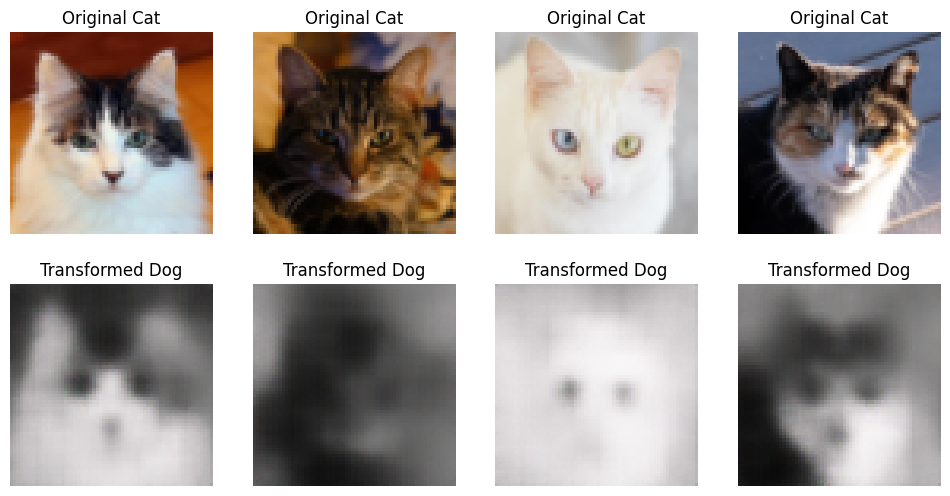

In [ ]:
# Load best model
model.load_state_dict(state_dict)
visualize_transformation(model, val_loader, device)

In [ ]:
def show_generated_image(model, label):
    z = torch.randn(1, 256).to(device)
    y = torch.tensor([label]).to(device)
    
    # Generate
    recon = model.decode(z, y)
    
    # Move to CPU and format for Plotting (Channels Last)
    # Shape becomes (64, 64, 3)
    img = recon[0].permute(1, 2, 0).detach().cpu().numpy()
    
    plt.imshow(img) # Matplotlib treats 0.0-1.0 as valid RGB colors
    plt.title(f"Generated Class {label}")
    plt.show()

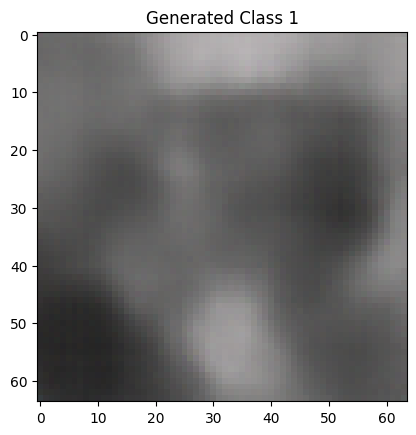

In [ ]:
show_generated_image(model, 1)